<a href="https://colab.research.google.com/github/Thorfast191/Monocular-Metric-Depth-Estimation/blob/main/MMDE_V2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MOUNT DRIVE

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Config

In [2]:
import os, cv2, numpy as np, torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import timm
from tqdm import tqdm
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


In [3]:
root = "/content/drive/MyDrive/Datasets/NYU Depth V2/nyu_data"

train_csv = os.path.join(root, "data/nyu2_train.csv")
test_csv  = os.path.join(root, "data/nyu2_test.csv")

train_df = pd.read_csv(train_csv, header=None)
test_df  = pd.read_csv(test_csv, header=None)

train_df.columns = ['image', 'depth']
test_df.columns  = ['image', 'depth']

train_df['image'] = train_df['image'].apply(lambda x: os.path.join(root, x))
train_df['depth'] = train_df['depth'].apply(lambda x: os.path.join(root, x))

test_df['image'] = test_df['image'].apply(lambda x: os.path.join(root, x))
test_df['depth'] = test_df['depth'].apply(lambda x: os.path.join(root, x))

# smaller subset for prototype
train_df = train_df.sample(1600, random_state=42).reset_index(drop=True)
test_df  = test_df.sample(400, random_state=42).reset_index(drop=True)

# Data Pre-process

In [4]:
class DepthDataset(Dataset):
    def __init__(self, df, size=(224,224), augment=False):
        self.df = df
        self.size = size
        self.augment = augment

        self.mean = np.array([0.485, 0.456, 0.406])
        self.std  = np.array([0.229, 0.224, 0.225])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img = cv2.imread(row['image'])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        depth = cv2.imread(row['depth'], -1).astype(np.float32)

        # ✅ FIX: relative depth
        depth = depth / 255.0

        # mask
        mask = depth > 0.01

        # resize
        img = cv2.resize(img, self.size)
        depth = cv2.resize(depth, self.size, interpolation=cv2.INTER_NEAREST)
        mask = cv2.resize(mask.astype(np.float32), self.size, interpolation=cv2.INTER_NEAREST) > 0

        # augmentation
        if self.augment and np.random.rand() > 0.5:
            img = np.fliplr(img).copy()
            depth = np.fliplr(depth).copy()
            mask = np.fliplr(mask).copy()

        img = img.astype(np.float32) / 255.0
        img = (img - self.mean) / self.std

        img = torch.from_numpy(img).permute(2,0,1).float()
        depth = torch.from_numpy(depth).float()
        mask = torch.from_numpy(mask).bool()

        return img, depth, mask

# Data loader

In [5]:
train_loader = DataLoader(
    DepthDataset(train_df, augment=True),
    batch_size=8,
    shuffle=True
)

test_loader = DataLoader(
    DepthDataset(test_df),
    batch_size=8
)

# Data Pre-proccessing Evaluation & Visualization


In [6]:
print("\n===== PREPROCESSING VALIDATION =====")

imgs, depths, masks = next(iter(train_loader))

print("Images:", imgs.shape)
print("Depths:", depths.shape)
print("Masks :", masks.shape)

print("\nDepth Range:")
print("Min:", depths.min().item())
print("Max:", depths.max().item())

print("\nDepth Stats:")
print("Mean:", depths.mean().item())
print("Std :", depths.std().item())

valid_ratio = masks.float().mean().item()
print("\nValid Depth Ratio:", valid_ratio)

print("\nNaN Check:")
print("Images:", torch.isnan(imgs).any().item())
print("Depths:", torch.isnan(depths).any().item())


===== PREPROCESSING VALIDATION =====
Images: torch.Size([8, 3, 224, 224])
Depths: torch.Size([8, 224, 224])
Masks : torch.Size([8, 224, 224])

Depth Range:
Min: 0.07058823853731155
Max: 0.9960784316062927

Depth Stats:
Mean: 0.28866109251976013
Std : 0.18884871900081635

Valid Depth Ratio: 1.0

NaN Check:
Images: False
Depths: False


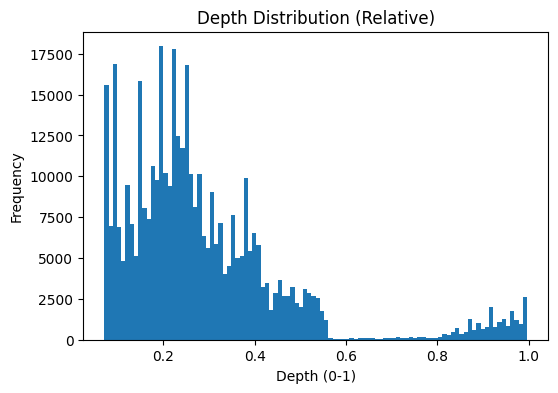

In [7]:
plt.figure(figsize=(6,4))
plt.hist(depths.flatten().numpy(), bins=100)
plt.title("Depth Distribution (Relative)")
plt.xlabel("Depth (0-1)")
plt.ylabel("Frequency")
plt.show()

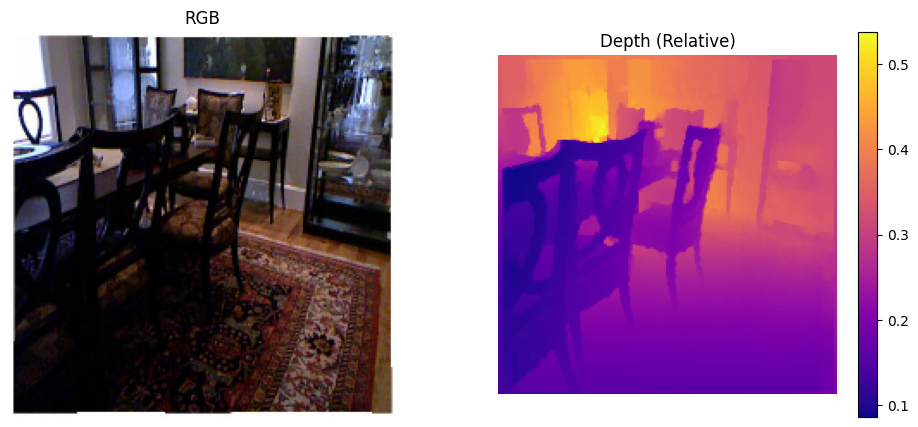

In [8]:
img = imgs[0]
depth = depths[0]

img_vis = img.permute(1,2,0).numpy()

mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

img_vis = (img_vis * std) + mean
img_vis = np.clip(img_vis, 0, 1)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.title("RGB")
plt.imshow(img_vis)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Depth (Relative)")
plt.imshow(depth.numpy(), cmap='plasma')
plt.colorbar()
plt.axis("off")

plt.show()

#  DPT-Lite Model (timm ViT backbone)

In [9]:
class DPT(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = timm.create_model(
            'vit_base_patch16_224',
            pretrained=True,
            features_only=True
        )

        channels = self.encoder.feature_info.channels()

        self.reduce = nn.ModuleList([nn.Conv2d(c, 256, 1) for c in channels])

        self.fuse = nn.Sequential(
            nn.Conv2d(256,256,3,padding=1),
            nn.ReLU(),
            nn.Conv2d(256,256,3,padding=1),
            nn.ReLU()
        )

        self.head = nn.Sequential(
            nn.Conv2d(256,128,3,padding=1),
            nn.ReLU(),
            nn.Conv2d(128,1,1)
        )

    def forward(self, x):
        feats = self.encoder(x)
        feats = [r(f) for r,f in zip(self.reduce, feats)]

        x = feats[-1]

        for f in reversed(feats[:-1]):
            x = F.interpolate(x, size=f.shape[-2:], mode='bilinear', align_corners=False)
            x = x + f

        x = self.fuse(x)
        x = self.head(x)

        x = F.interpolate(x, size=(224,224), mode='bilinear', align_corners=False)

        return torch.sigmoid(x)

# Combine Loss

In [10]:
def gradient_loss(pred, target):

    # pred, target: (B, H, W)

    dy_pred = torch.abs(pred[:, 1:, :] - pred[:, :-1, :])
    dy_gt   = torch.abs(target[:, 1:, :] - target[:, :-1, :])

    dx_pred = torch.abs(pred[:, :, 1:] - pred[:, :, :-1])
    dx_gt   = torch.abs(target[:, :, 1:] - target[:, :, :-1])

    return (dx_pred - dx_gt).abs().mean() + (dy_pred - dy_gt).abs().mean()


def silog_loss(pred, target):
    pred = torch.clamp(pred, 1e-3, 1)
    target = torch.clamp(target, 1e-3, 1)

    log_diff = torch.log(pred) - torch.log(target)

    return torch.sqrt((log_diff**2).mean() - 0.85*(log_diff.mean()**2))


def combined_loss(pred, target, mask):

    # --- GLOBAL (structure preserving) ---
    grad = gradient_loss(pred, target)

    # --- MASKED (valid pixels only) ---
    pred_masked = pred[mask]
    target_masked = target[mask]

    silog = silog_loss(pred_masked, target_masked)
    l1 = torch.abs(pred_masked - target_masked).mean()

    return 0.5*silog + 0.3*l1 + 0.2*grad

# Training Loop

In [11]:
model = DPT().to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [12]:
# Checkpoint paths
save_dir = "/content/drive/MyDrive/checkpoints/MMDE-V2"
os.makedirs(save_dir, exist_ok=True)

latest_path = os.path.join(save_dir, "latest.pth")
best_path   = os.path.join(save_dir, "best.pth")

start_epoch = 0
best_loss = float("inf")

start_epoch = 0
best_loss = float("inf")

if os.path.exists(latest_path):
    print("🔄 Loading checkpoint...")
    ckpt = torch.load(latest_path, map_location=device)

    model.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    scheduler.load_state_dict(ckpt['scheduler_state_dict'])

    start_epoch = ckpt['epoch'] + 1
    best_loss = ckpt.get('best_loss', float("inf"))

    print(f"✅ Resumed from epoch {start_epoch}")

In [13]:
EPOCHS = 10

for epoch in range(start_epoch, EPOCHS):
    model.train()
    total_loss = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}")

    for img, depth, mask in pbar:
        img, depth, mask = img.to(device), depth.to(device), mask.to(device)

        pred = model(img).squeeze(1)
        loss = combined_loss(pred, depth, mask)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        pbar.set_postfix(loss=loss.item())

    scheduler.step()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}: Avg Loss = {avg_loss:.4f}")

    # SAVE LATEST
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'best_loss': best_loss
    }, latest_path)

    print("💾 Saved latest checkpoint")

    # SAVE BEST
    if avg_loss < best_loss:
        best_loss = avg_loss

        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'loss': best_loss
        }, best_path)

        print("🏆 Best model updated!")

Epoch 1: 100%|██████████| 200/200 [01:39<00:00,  2.02it/s, loss=0.165]


Epoch 1: Avg Loss = 0.1880
💾 Saved latest checkpoint
🏆 Best model updated!


Epoch 2: 100%|██████████| 200/200 [01:45<00:00,  1.90it/s, loss=0.121]


Epoch 2: Avg Loss = 0.1365
💾 Saved latest checkpoint
🏆 Best model updated!


Epoch 3: 100%|██████████| 200/200 [02:33<00:00,  1.30it/s, loss=0.13]


...

Epoch 8: Avg Loss = 0.0768
💾 Saved latest checkpoint
🏆 Best model updated!


Epoch 9: 100%|██████████| 200/200 [02:30<00:00,  1.33it/s, loss=0.0714]


Epoch 9: Avg Loss = 0.0731
💾 Saved latest checkpoint
🏆 Best model updated!


Epoch 10: 100%|██████████| 200/200 [02:05<00:00,  1.59it/s, loss=0.0689]


Epoch 10: Avg Loss = 0.0690
💾 Saved latest checkpoint
🏆 Best model updated!


#  Evaluation Metrics

In [14]:
def compute_metrics(pred, target, mask):
    pred = pred[mask]
    target = target[mask]

    rmse = torch.sqrt(((pred-target)**2).mean())
    abs_rel = torch.mean(torch.abs(pred-target)/target)

    ratio = torch.max(pred/target, target/pred)

    d1 = (ratio < 1.25).float().mean()
    d2 = (ratio < 1.25**2).float().mean()
    d3 = (ratio < 1.25**3).float().mean()

    return rmse.item(), abs_rel.item(), d1.item(), d2.item(), d3.item()


model.eval()

rmse_total, absrel_total = 0, 0
d1_total, d2_total, d3_total = 0, 0, 0
count = 0

with torch.no_grad():
    for img, depth, mask in test_loader:
        img, depth, mask = img.to(device), depth.to(device), mask.to(device)

        pred = model(img).squeeze(1)

        rmse, absrel, d1, d2, d3 = compute_metrics(pred, depth, mask)

        rmse_total += rmse
        absrel_total += absrel
        d1_total += d1
        d2_total += d2
        d3_total += d3
        count += 1

print("\n===== TEST RESULTS =====")
print(f"RMSE   : {rmse_total/count:.4f}")
print(f"AbsRel : {absrel_total/count:.4f}")
print(f"δ1     : {d1_total/count:.4f}")
print(f"δ2     : {d2_total/count:.4f}")
print(f"δ3     : {d3_total/count:.4f}")


===== TEST RESULTS =====
RMSE   : 11.7208
AbsRel : 0.9729
δ1     : 0.0000
δ2     : 0.0000
δ3     : 0.0000


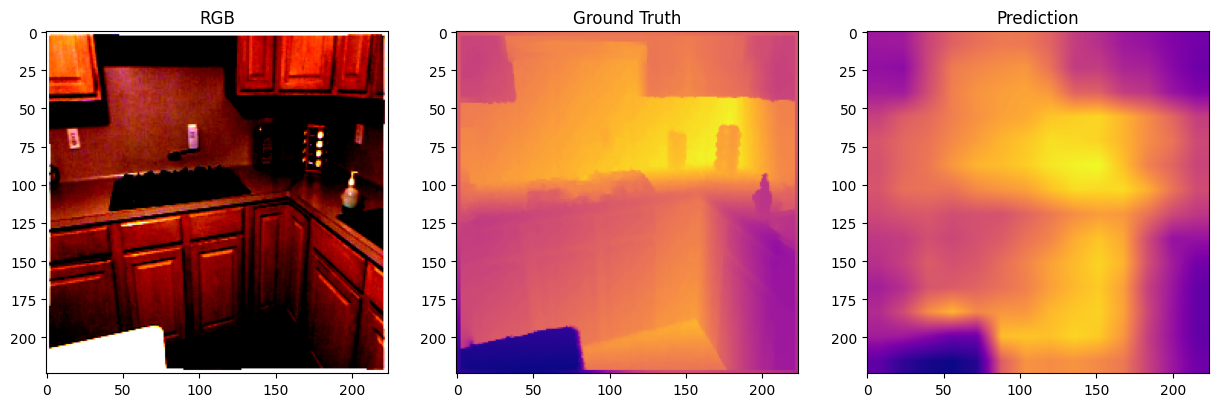

In [15]:
model.eval()

with torch.no_grad():
    img, depth, mask = next(iter(test_loader))
    img = img.to(device)

    pred = model(img).squeeze(1).cpu()

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.title("RGB")
plt.imshow(img[0].cpu().permute(1,2,0))

plt.subplot(1,3,2)
plt.title("Ground Truth")
plt.imshow(depth[0], cmap='plasma')

plt.subplot(1,3,3)
plt.title("Prediction")
plt.imshow(pred[0], cmap='plasma')

plt.show()